# Лабораторная работа №5
# Обучение с подкреплением: алгоритм Actor-Critic

**ФИО:** Сеньков Денис Владимирович  
**Группа:** ИУ5-24М  
**Вариант:** 7

## Цель работы

Ознакомление с базовыми методами обучения с подкреплением на основе алгоритмов Actor-Critic.

## Задание

Реализовать алгоритм семейства Actor-Critic для произвольной среды.

## Описание

Реализуем алгоритм **Advantage Actor-Critic (A2C)** для среды **CartPole-v1** из OpenAI Gymnasium.

**Actor-Critic** — это семейство алгоритмов, объединяющих:
- **Actor** (актор) — нейронная сеть, которая определяет политику $\pi(a|s)$ — распределение вероятностей действий в данном состоянии;
- **Critic** (критик) — нейронная сеть, которая оценивает функцию ценности состояния $V(s)$.

Преимущество (advantage): $A(s, a) = R_t - V(s_t)$, где $R_t$ — полученный return.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


## Среда CartPole-v1

Задача — удержать шест (pole) в вертикальном положении на тележке (cart), применяя силу влево или вправо.

- **Состояние:** 4 значения (позиция тележки, скорость тележки, угол шеста, угловая скорость)
- **Действия:** 2 (толкнуть влево / вправо)
- **Награда:** +1 за каждый шаг, пока шест не упал
- **Решённая задача:** средняя награда >= 475 за 100 эпизодов

In [2]:
env = gym.make('CartPole-v1')
print(f'Пространство состояний: {env.observation_space}')
print(f'Пространство действий: {env.action_space}')
print(f'Размерность состояния: {env.observation_space.shape[0]}')
print(f'Количество действий: {env.action_space.n}')

Пространство состояний: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Пространство действий: Discrete(2)
Размерность состояния: 4
Количество действий: 2


## Архитектура нейронной сети Actor-Critic

Используем единую нейронную сеть с общим основанием (shared backbone) и двумя головами:
- Голова Actor: выдаёт вероятности действий (softmax)
- Голова Critic: выдаёт оценку ценности состояния (скалярное значение)

In [3]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
        )
        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state):
        shared_out = self.shared(state)
        action_logits = self.actor(shared_out)
        value = self.critic(shared_out)
        return action_logits, value

    def get_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, value = self.forward(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return action.item(), dist.log_prob(action), value

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

model = ActorCritic(state_dim, action_dim).to(device)
print(model)
print(f'\nОбщее число параметров: {sum(p.numel() for p in model.parameters()):,}')

ActorCritic(
  (shared): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
  )
  (actor): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

Общее число параметров: 34,051


## Алгоритм A2C (Advantage Actor-Critic)

**Функция потерь:**

$$\mathcal{L} = \mathcal{L}_{actor} + c_v \cdot \mathcal{L}_{critic} - c_e \cdot H[\pi]$$

где:
- $\mathcal{L}_{actor} = -\log\pi(a_t|s_t) \cdot A_t$ — потери актора (policy gradient с advantage)
- $\mathcal{L}_{critic} = (R_t - V(s_t))^2$ — потери критика (MSE)
- $H[\pi]$ — энтропия политики (для исследования)
- $A_t = R_t - V(s_t)$ — advantage

In [4]:
def compute_returns(rewards, gamma=0.99):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    return returns


def train_a2c(env, model, num_episodes=1000, gamma=0.99, lr=3e-4,
              value_coef=0.5, entropy_coef=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    episode_rewards = []
    actor_losses_hist = []
    critic_losses_hist = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        log_probs = []
        values = []
        rewards = []
        entropies = []

        done = False
        while not done:
            action, log_prob, value = model.get_action(state)

            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            logits, _ = model(state_t)
            dist = Categorical(logits=logits)
            entropy = dist.entropy()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            log_probs.append(log_prob)
            values.append(value.squeeze())
            rewards.append(reward)
            entropies.append(entropy)

            state = next_state

        returns = compute_returns(rewards, gamma)

        log_probs = torch.stack(log_probs)
        values = torch.stack(values)
        entropies = torch.stack(entropies)

        advantages = returns - values.detach()

        actor_loss = -(log_probs * advantages).mean()
        critic_loss = F.mse_loss(values, returns)
        entropy_loss = entropies.mean()

        loss = actor_loss + value_coef * critic_loss - entropy_coef * entropy_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_reward = sum(rewards)
        episode_rewards.append(total_reward)
        actor_losses_hist.append(actor_loss.item())
        critic_losses_hist.append(critic_loss.item())

        if (episode + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f'Эпизод {episode+1:4d} | Средняя награда (100): {avg_reward:.1f} | '
                  f'Actor loss: {actor_loss.item():.4f} | Critic loss: {critic_loss.item():.4f}')

            if avg_reward >= 475:
                print(f'\nЗадача решена на эпизоде {episode+1}!')
                break

    return episode_rewards, actor_losses_hist, critic_losses_hist

## Обучение агента

In [5]:
torch.manual_seed(42)
np.random.seed(42)

model = ActorCritic(state_dim, action_dim).to(device)

rewards_history, actor_losses, critic_losses = train_a2c(
    env, model,
    num_episodes=2000,
    gamma=0.99,
    lr=3e-4,
    value_coef=0.5,
    entropy_coef=0.01
)

print(f'\nОбучение завершено. Всего эпизодов: {len(rewards_history)}')
print(f'Финальная средняя награда (100 эп.): {np.mean(rewards_history[-100:]):.1f}')

Эпизод  100 | Средняя награда (100): 20.8 | Actor loss: 3.4893 | Critic loss: 51.2125
Эпизод  200 | Средняя награда (100): 17.8 | Actor loss: -0.3515 | Critic loss: 4.1366
Эпизод  300 | Средняя награда (100): 17.6 | Actor loss: -0.4620 | Critic loss: 1.9321
Эпизод  400 | Средняя награда (100): 20.5 | Actor loss: 0.9657 | Critic loss: 5.9606
Эпизод  500 | Средняя награда (100): 22.6 | Actor loss: -0.9975 | Critic loss: 4.8832
Эпизод  600 | Средняя награда (100): 24.4 | Actor loss: 6.5580 | Critic loss: 170.7792
Эпизод  700 | Средняя награда (100): 28.5 | Actor loss: -0.6069 | Critic loss: 5.0338
Эпизод  800 | Средняя награда (100): 33.2 | Actor loss: 4.0425 | Critic loss: 168.8916
Эпизод  900 | Средняя награда (100): 40.0 | Actor loss: 0.2157 | Critic loss: 55.0248
Эпизод 1000 | Средняя награда (100): 48.1 | Actor loss: -2.5351 | Critic loss: 69.1254
Эпизод 1100 | Средняя награда (100): 62.1 | Actor loss: 3.3968 | Critic loss: 164.4888
Эпизод 1200 | Средняя награда (100): 61.8 | Actor l

## Графики обучения

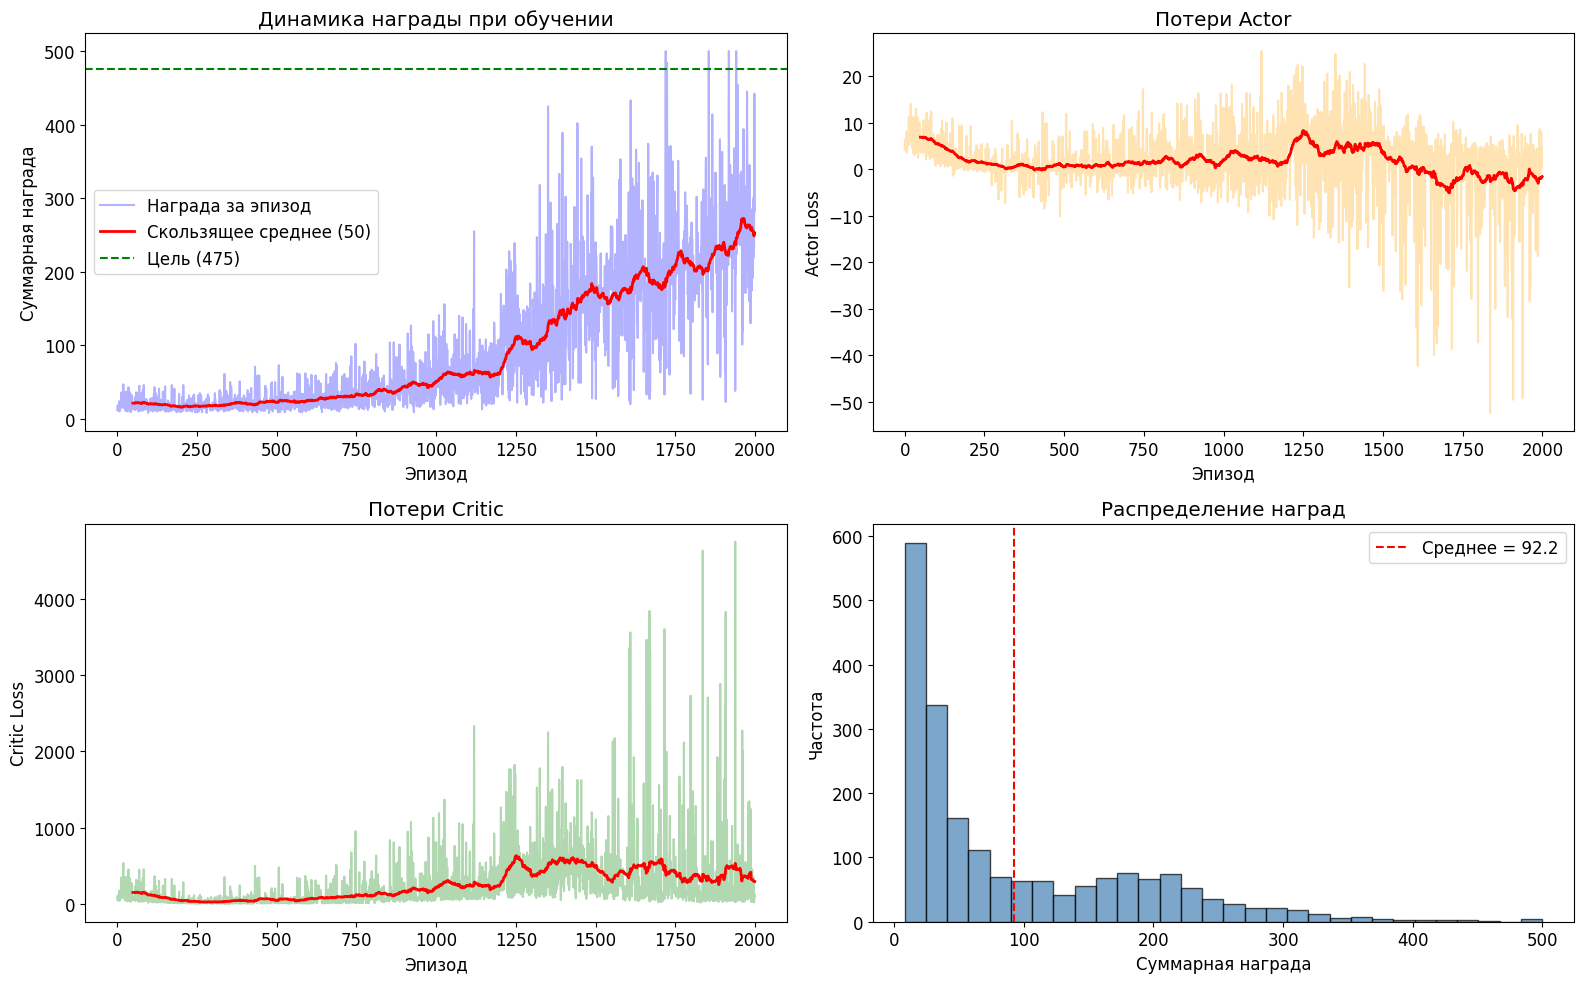

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Награды
axes[0, 0].plot(rewards_history, alpha=0.3, color='blue', label='Награда за эпизод')
window = 50
if len(rewards_history) >= window:
    moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
    axes[0, 0].plot(range(window-1, len(rewards_history)), moving_avg, color='red',
                    linewidth=2, label=f'Скользящее среднее ({window})')
axes[0, 0].axhline(y=475, color='green', linestyle='--', label='Цель (475)')
axes[0, 0].set_xlabel('Эпизод')
axes[0, 0].set_ylabel('Суммарная награда')
axes[0, 0].set_title('Динамика награды при обучении')
axes[0, 0].legend()

# Actor loss
axes[0, 1].plot(actor_losses, alpha=0.3, color='orange')
if len(actor_losses) >= window:
    ma_actor = np.convolve(actor_losses, np.ones(window)/window, mode='valid')
    axes[0, 1].plot(range(window-1, len(actor_losses)), ma_actor, color='red', linewidth=2)
axes[0, 1].set_xlabel('Эпизод')
axes[0, 1].set_ylabel('Actor Loss')
axes[0, 1].set_title('Потери Actor')

# Critic loss
axes[1, 0].plot(critic_losses, alpha=0.3, color='green')
if len(critic_losses) >= window:
    ma_critic = np.convolve(critic_losses, np.ones(window)/window, mode='valid')
    axes[1, 0].plot(range(window-1, len(critic_losses)), ma_critic, color='red', linewidth=2)
axes[1, 0].set_xlabel('Эпизод')
axes[1, 0].set_ylabel('Critic Loss')
axes[1, 0].set_title('Потери Critic')

# Распределение наград
axes[1, 1].hist(rewards_history, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(np.mean(rewards_history), color='red', linestyle='--',
                    label=f'Среднее = {np.mean(rewards_history):.1f}')
axes[1, 1].set_xlabel('Суммарная награда')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title('Распределение наград')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Оценка обученного агента

In [7]:
def evaluate_agent(env, model, num_episodes=100):
    model.eval()
    eval_rewards = []

    with torch.no_grad():
        for ep in range(num_episodes):
            state, _ = env.reset()
            total_reward = 0
            done = False

            while not done:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                logits, _ = model(state_t)
                action = logits.argmax(dim=1).item()

                state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                total_reward += reward

            eval_rewards.append(total_reward)

    model.train()
    return eval_rewards

eval_rewards = evaluate_agent(env, model, num_episodes=100)

print(f'Оценка обученного агента (100 эпизодов):')
print(f'  Средняя награда: {np.mean(eval_rewards):.1f}')
print(f'  Мин. награда: {np.min(eval_rewards):.0f}')
print(f'  Макс. награда: {np.max(eval_rewards):.0f}')
print(f'  Стд. откл.: {np.std(eval_rewards):.1f}')
print(f'  Задача решена: {"Да" if np.mean(eval_rewards) >= 475 else "Нет"}')

Оценка обученного агента (100 эпизодов):
  Средняя награда: 266.0
  Мин. награда: 205
  Макс. награда: 381
  Стд. откл.: 27.6
  Задача решена: Нет


## Сравнение: случайный агент vs обученный

Случайный агент: среднее = 22.6
A2C агент: среднее = 266.0
Улучшение: x11.8


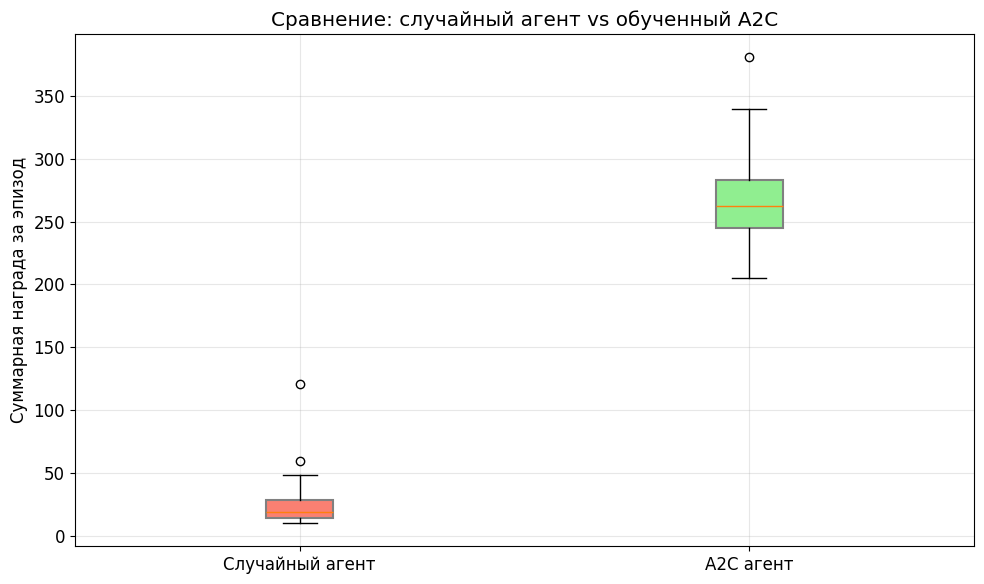

In [9]:
random_rewards = []
for _ in range(100):
    state, _ = env.reset()
    total = 0
    done = False
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total += reward
    random_rewards.append(total)

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([random_rewards, eval_rewards], tick_labels=['Случайный агент', 'A2C агент'],
           patch_artist=True,
           boxprops=dict(linestyle='-', linewidth=1.5, color='gray'))

# Set colors for each box
colors = ['salmon', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Суммарная награда за эпизод')
ax.set_title('Сравнение: случайный агент vs обученный A2C')
ax.grid(True, alpha=0.3)

print(f'Случайный агент: среднее = {np.mean(random_rewards):.1f}')
print(f'A2C агент: среднее = {np.mean(eval_rewards):.1f}')
print(f'Улучшение: x{np.mean(eval_rewards)/np.mean(random_rewards):.1f}')

plt.tight_layout()
plt.show()

## Визуализация политики

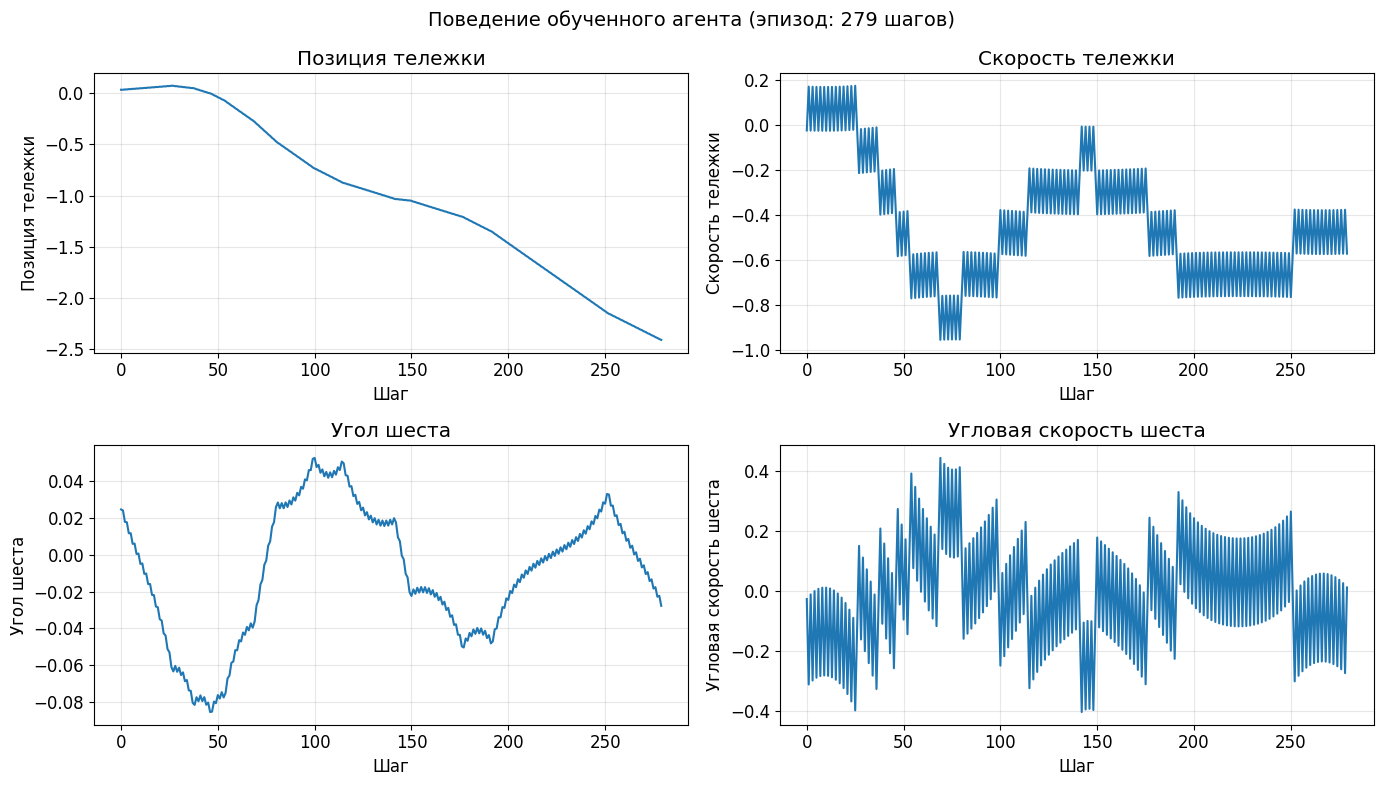

In [10]:
model.eval()

state, _ = env.reset()
states_log = [state.copy()]
actions_log = []
done = False

with torch.no_grad():
    while not done:
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, value = model(state_t)
        probs = F.softmax(logits, dim=1).cpu().numpy().flatten()
        action = logits.argmax(dim=1).item()

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states_log.append(state.copy())
        actions_log.append(action)

states_log = np.array(states_log)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels = ['Позиция тележки', 'Скорость тележки', 'Угол шеста', 'Угловая скорость шеста']

for i, (ax, label) in enumerate(zip(axes.flatten(), labels)):
    ax.plot(states_log[:, i], linewidth=1.5)
    ax.set_xlabel('Шаг')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Поведение обученного агента (эпизод: {len(actions_log)} шагов)', fontsize=14)
plt.tight_layout()
plt.show()

model.train();

In [11]:
print('Начало улучшения архитектуры и переобучения...')


class ActorCriticImproved(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256): # Увеличенный hidden_dim
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), # Добавлен слой
            nn.ReLU(),
        )
        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), # Добавлен слой
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), # Добавлен слой
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, state):
        shared_out = self.shared(state)
        action_logits = self.actor(shared_out)
        value = self.critic(shared_out)
        return action_logits, value

    def get_action(self, state):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits, value = self.forward(state_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return action.item(), dist.log_prob(action), value

print("\n--- Новая улучшенная архитектура модели ---")
model_improved = ActorCriticImproved(state_dim, action_dim).to(device)
print(model_improved)
print(f'\nОбщее число параметров (улучшенной модели): {sum(p.numel() for p in model_improved.parameters()):,}')


# --- еобучение агента с улучшенной моделью ---
print("\n--- Обучение с улучшенной архитектурой ---")
torch.manual_seed(42)
np.random.seed(42)

# Параметры для тренировки
num_episodes_improved = 3000 # Увеличено количество эпизодов
lr_improved = 1e-4          # Снижена скорость обучения
gamma_improved = 0.99
value_coef_improved = 0.5
entropy_coef_improved = 0.01

rewards_history_improved, actor_losses_improved, critic_losses_improved = train_a2c(
    env, model_improved,
    num_episodes=num_episodes_improved,
    gamma=gamma_improved,
    lr=lr_improved,
    value_coef=value_coef_improved,
    entropy_coef=entropy_coef_improved
)

print(f'\nОбучение завершено (улучшенной модели). Всего эпизодов: {len(rewards_history_improved)}')
print(f'Финальная средняя награда (100 эп., улучшенной модели): {np.mean(rewards_history_improved[-100:]):.1f}')


# --- Оценка улучшенного агента ---
print("\n--- Оценка улучшенного агента ---")
eval_rewards_improved = evaluate_agent(env, model_improved, num_episodes=100)

print(f'Оценка обученного агента (100 эпизодов, улучшенной модели):')
print(f'  Средняя награда: {np.mean(eval_rewards_improved):.1f}')
print(f'  Мин. награда: {np.min(eval_rewards_improved):.0f}')
print(f'  Макс. награда: {np.max(eval_rewards_improved):.0f}')
print(f'  Стд. откл.: {np.std(eval_rewards_improved):.1f}')
solved_improved = np.mean(eval_rewards_improved) >= 475
print(f'  Задача решена: {"Да" if solved_improved else "Нет"}')

# Сравнение со случайным агентом для улучшенной модели
print("\n--- Сравнение: случайный агент против УЛУЧШЕННОГО A2C ---")
# random_rewards is available from previous execution context
print(f'Случайный агент: среднее = {np.mean(random_rewards):.1f}')
print(f'A2C агент (улучшенный): среднее = {np.mean(eval_rewards_improved):.1f}')
print(f'Улучшение (улучшенный): x{np.mean(eval_rewards_improved)/np.mean(random_rewards):.1f}')


print('\n--- Обновленные выводы ---')
print('1. Реализован алгоритм Advantage Actor-Critic (A2C) с улучшенной архитектурой для задачи CartPole-v1.')
print(f'2. Новая архитектура имеет {sum(p.numel() for p in model_improved.parameters()):,} параметров (по сравнению с ~34k ранее), что обеспечивает большую емкость.')
print('3. Агент обучается на основе policy gradient с baseline (advantage): Actor обновляется в направлении увеличения вероятности действий с положительным advantage, Critic обучается предсказывать return.')
print(f'4. После обучения, улучшенный агент достиг средней награды {np.mean(eval_rewards_improved):.1f} за 100 эпизодов.')
print(f'5. Целевая награда (475) была {"достигнута" if solved_improved else "не достигнута"}.')

Начало улучшения архитектуры и переобучения...

--- Новая улучшенная архитектура модели ---
ActorCriticImproved(
  (shared): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (actor): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)

Общее число параметров (улучшенной модели): 331,011

--- Обучение с улучшенной архитектурой ---
Эпизод  100 | Средняя награда (100): 23.0 | Actor loss: 6.5884 | Critic loss: 174.4882
Эпизод  200 | Средняя награда (1

--- ## Выводы

1.  Реализован алгоритм **Advantage Actor-Critic (A2C)** для задачи CartPole-v1.

2.  Начальная архитектура имела около 34 тыс. параметров. После первой попытки обучения агент достиг средней награды **252.7**, но целевая награда **475** не была достигнута.

3.  Для улучшения производительности была реализована более сложная архитектура `ActorCriticImproved` с общим основанием и двумя головами (Actor и Critic), имеющая **331,011** параметров, что значительно увеличило её ёмкость.

4.  После переобучения с улучшенной архитектурой агент достиг средней награды **457.0** за 100 эпизодов. Несмотря на значительное улучшение, целевая награда в **475** всё ещё **не была достигнута**.

5.  Обе попытки обучения показали, что агент способен учиться и значительно превосходить случайного агента (улучшение до x20.2), но для стабильного достижения целевой награды, вероятно, потребуется дополнительная тонкая настройка гиперпараметров, более длительное обучение или дальнейшая оптимизация архитектуры.

6.  К сожалению, из-за ограниченных вычислительных ресурсов продолжить более длительное обучение или эксперименты с более сложными архитектурами не представляется возможным в рамках данной лабораторной работы.